Algoritmos Genéticos y Optimización Heurística - UTN-FRT
# **Trabajo Práctico N°2 - Opcional**
## **Tema**: Simulated Annealing##

Arnedo Emmanuel - 52304  
Arnedo Mateo - 53813  
Zelarayan Camila - 57261

## Ejercicio 1

Completamos las tres partes que faltaban (marcadas con #COMPLETADO):

- Si el número al azar es menor que la probabilidad $p$, la solución peor pasa a ser la actual. Es el criterio de Metrópolis que le permite al algoritmo escapar de óptimos locales.
- Usamos el esquema de enfriamiento exponencial $T(i) = T_0 \, e^{-\mu i}$, donde $i$ es la iteración actual. La temperatura desciende rápidamente al comienzo y de manera asintótica hacia el final, manteniéndose siempre positiva.
- Para el entorno de búsqueda (`puntoExploracion`), generamos desplazamientos independientes por coordenada uniformemente distribuidos en $[-max\_eps, max\_eps]$. Esto define una vecindad hipercúbica que permite explorar eficientemente el espacio sin sesgos direccionales y facilita el ajuste fino local.

También agregamos un parámetro opcional `verbose` para desactivar la impresión por pantalla en corridas extensas y pruebas de validación masivas.

In [1]:
import random
import math

def SimulatedAnnealing(fitness, X_mejor, max_eps, bounds, cant_iterac, T0, mu, verbose=True):
    """Método de optimización Simulated Annealing
    PARAMETROS
    fitness : function
        Funcion de evaluacion a optimizar
    X_mejor: list
        Vector solucion inicial, desde donde parte la exploracion.
    max_eps: float
        Valor de distancia maxima del paso a recorrer en cada iteracion.
    bounds: list(tuple)
        Matriz de tamano nx2, donde n es la cantidad de variables que
        tiene el problema (cantidad de coordenadas del vector solución).
        En la primera columna se establecen los valores limites inferiores y
        en la segunda columna se establece los valores limite superiores.
        Observen que los valores de la primera columna siempre deben ser
        menores que los de la segunda).
    cant_iterac: integer
        Cantidad de iteraciones usada como condicion de terminacion.
    T0: float
        temperatura inicial (depende de los valores de fitness).
    mu: float
        factor que controla la forma de la función de enfriamiento.
    RETORNO
    X_mejor : list
        Vector solución correspondiente a la mejor solución encontrada.
    fX_mejor : list
        Valor de evaluación de la mejores solución encontrada.
    Trace_R : list
        Lista con los vectores dirección calculados en cada iteración.
    Trace_X : list
        Lista con las soluciones calculadas en cada iteración.
    Trace_X_mejor : list
        Lista con las mejores soluciones de cada iteración.
    Trace_f : list
        Lista con los valores de evaluación de la mejor y peor solución.
    """
    fX_mejor = 0
    Trace_R = []
    Trace_X = []
    Trace_X_mejor = []
    Trace_f = []
    if len(X_mejor) == 0:
        print ('La solucion inicial debe tener al menos una variable.')
        return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f
    if len(bounds) != len(X_mejor) or len(bounds[0]) != 2:
        print('La matriz de Bounds tiene un tamaño incorrecto.')
        return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f
    if cant_iterac < 1:
        print('El número máximo de iteraciones debe ser positivo mayor a cero.')
        return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f
    if T0 <= 0:
        print('La temperatura inicial debe ser positiva.')
        return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f
    if max_eps <= 0:
        print('El tamaño del paso debe ser real y positivo.')
        return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f
    # Evaluacion inicial
    fX_mejor = fitness(X_mejor)
    fX_best = fX_mejor
    T = T0;
    
    # Inicializar variables
    Trace_R.append([0 for xi in X_mejor]);
    Trace_X.append(X_mejor);
    Trace_X_mejor.append(X_mejor);
    Trace_f.append((fX_mejor,fX_mejor))
    it = 0
    cnt = 0
    sigue = True
    
    # Repetir hasta que se cumpla la condicion de terminacion
    while sigue:
        # Temperatura actual
        T = temperaturaSA(it, T0, mu)
        #  Calculo el punto de exploracion
        X, R = puntoExploracion(X_mejor, max_eps)
        
        # Verifico y corrijo que X este dentro del dominio
        for i in range(len(X)):
            X[i] = bounds[i][0] if X[i] < bounds[i][0] else X[i]
            X[i] = bounds[i][1] if X[i] > bounds[i][1] else X[i]
            
        # Evaluo solucion
        fX0 = fX_mejor
        fX = fitness(X)
        
        # Si la solucion actual es mejor que la que ya tenía
        if fX >= fX_mejor:
            X_mejor = X
            fX_mejor = fX
            cnt = 0
        else:
            cnt = cnt + 1
            #T iro una moneda para saber si acepto la solucion de todas formas
            p = probabilidadSA(fX, fX_mejor, T)

            if random.random() < p:
                # COMPLETADO: acepto la solución peor, pasa a ser la actual.

                X_mejor = X
                fX_mejor = fX

        # Guardo valores para analisis posterior
        Trace_R.append(R)
        Trace_X.append(X)
        Trace_X_mejor.append(X_mejor)
        Trace_f.append((max(fX, fX0), min(fX, fX0)))
        # Condicion de terminacion
        if cnt > cant_iterac:
            sigue = False
        # Incremento el tiempo
        it = it + 1
        # imprimir solo si obtuve una mejor solucion
        if verbose and fX >= fX0:
            print("It.{0}: {1} -> {2}".format(it,
                [round(xi,2) for xi in X], round(fX_mejor,4)))
    return X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f

def temperaturaSA(i, T0, mu):
    """Temperatura en la iteración i. Enfriamiento exponencial: T = T0 * exp(-mu * i)."""
    # COMPLETADO
    T = T0 * math.exp(-mu * i)
    return T

def probabilidadSA(fX, fX_mejor, T):
    """Probabilidad de aceptar una solución peor (fX < fX_mejor)."""
    return math.exp((fX - fX_mejor) / T)

def puntoExploracion(X0, max_eps):
    """Anterior función de exploración, que genera un nuevo punto a distancia aleatoria (hasta max_eps) de X0, en una dirección aleatoria.
    Nuevo punto a distancia aleatoria (hasta max_eps) de X0, en una dirección aleatoria.
    R es un vector dirección unitario, uniforme sobre todas las direcciones posibles.
    # COMPLETADO
    # 1) Dirección: vector gaussiano normalizado  (uniforme sobre la esfera unitaria)
    R = [random.gauss(0, 1) for _ in X0]
    norma = math.sqrt(sum(r * r for r in R))
    R = [r / norma for r in R]
    # 2) Longitud del paso: uniforme entre 0 y max_eps
    paso = random.uniform(0, max_eps)
    # 3) Nuevo punto (lista NUEVA, no se modifica X0)
    X = [xi + paso * ri for xi, ri in zip(X0, R)]
    return X, R     """
    
    """Nuevo punto a distancia aleatoria (hasta max_eps) de X0."""  
    X = []
    R = []
    for xi in X0:
        # Genera un paso aleatorio entre -max_eps y max_eps
        paso = random.uniform(-max_eps, max_eps)
        R.append(paso)
        X.append(xi + paso)
    return X, R

### Funciones para graficar

Usamos las funciones de gráficos del enunciado y agregamos dos gráficos más:
- La caminata vista desde arriba, con curvas de nivel. En el gráfico 3D muchos puntos quedan tapados por la superficie.
- La evolución del fitness de la solución actual junto con el mejor encontrado, y debajo la temperatura.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap

AZUL = LinearSegmentedColormap.from_list('azul', plt.cm.Blues(np.linspace(0.35, 1, 256)))

# Colores
C = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3,
                    'axes.spines.top': False, 'axes.spines.right': False,
                    'axes.prop_cycle': plt.cycler(color=C)})

def graficarEvolucionFitness(trace_f):
    """Evolución del fitness."""
    plt.figure(figsize=(8, 3.5))
    x = list(range(len(trace_f)))
    plt.plot(x, [t[0] for t in trace_f], label='Mejor solución', lw=1)
    plt.plot(x, [t[1] for t in trace_f], label='Peor solución', lw=1, alpha=0.7)
    plt.title('Valores de evaluación (actual vs. candidata en cada iteración)')
    plt.xlabel('Iteración'); plt.ylabel('Fitness'); plt.legend(); plt.show()

def graficarTemperatura(T0, mu, cant_iterac):
    """Función de enfriamiento."""
    plt.figure(figsize=(8, 3))
    X = list(range(cant_iterac))
    plt.plot(X, [temperaturaSA(i, T0, mu) for i in X])
    plt.title(f'Función de temperatura  T(i) = {T0:g}·exp(-{mu:g}·i)')
    plt.xlabel('Iteración'); plt.ylabel('T(i)'); plt.show()

def graficarCaminata(fitness, solutions, bounds, resolution, alpha=0.5):
    """Función de evaluación y caminata."""
    if len(bounds) == 1:
        fig = plt.figure(figsize=(8, 4)); ax = fig.gca()
        xs = np.arange(bounds[0][0], bounds[0][1], resolution)
        ax.plot(xs, [fitness([xi]) for xi in xs], alpha=alpha, color='gray', label='g(x)')
        x = [s[0] for s in solutions]
        ax.scatter(x, [fitness(s) for s in solutions], c=range(len(x)), cmap=AZUL,
                s=10, edgecolors='none')
        ax.scatter(x[0], fitness(solutions[0]), c=C[1], s=80, marker='s', label='Inicio', zorder=5)
        ax.scatter(x[-1], fitness(solutions[-1]), c=C[2], s=150, marker='*', label='Final', zorder=5)
        plt.title('Función de evaluación y caminata (más oscuro = más tarde)')
        plt.xlabel('x'); plt.ylabel('f(x)'); plt.legend(); plt.show()
    elif len(bounds) == 2:
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(projection='3d')        # en matplotlib >= 3.4 reemplaza a gca(projection="3d")
        xs = np.arange(bounds[0][0], bounds[0][1], resolution)
        ys = np.arange(bounds[1][0], bounds[1][1], resolution)
        XX, YY = np.meshgrid(xs, ys)
        Z = np.vectorize(lambda a, b: fitness([a, b]))(XX, YY)
        surf = ax.plot_surface(XX, YY, Z, cmap=cm.coolwarm, linewidth=0, antialiased=False, alpha=alpha)
        plt.title('Función de evaluación y caminata')
        ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('f(x,y)')
        fig.colorbar(surf, shrink=0.5, aspect=5)
        ax.scatter([s[0] for s in solutions], [s[1] for s in solutions],
                [fitness(s) + 1 for s in solutions], c='k', marker='o', s=2)
        ax.view_init(elev=40., azim=60); plt.show()
    else:
        print("No implementado para más de dos variables.")

def graficarCaminataContorno(fitness, solutions, bounds, optimos=None, titulo=''):
    """Vista superior: curvas de nivel + caminata coloreada según la iteración."""
    xs = np.linspace(*bounds[0], 300); ys = np.linspace(*bounds[1], 300)
    XX, YY = np.meshgrid(xs, ys)
    Z = np.vectorize(lambda a, b: fitness([a, b]))(XX, YY)
    fig, ax = plt.subplots(figsize=(7, 6))
    cf = ax.contourf(XX, YY, Z, levels=30, cmap='Greys', alpha=0.55)
    fig.colorbar(cf, ax=ax, label='fitness')
    s = np.array(solutions)
    ax.plot(s[:, 0], s[:, 1], '-', color=C[0], lw=0.4, alpha=0.5)
    sc = ax.scatter(s[:, 0], s[:, 1], c=np.arange(len(s)), cmap=AZUL, s=6, zorder=3)
    fig.colorbar(sc, ax=ax, label='iteración')
    ax.scatter(*s[0], c=C[1], s=100, marker='s', label='Inicio', zorder=5, edgecolors='white')
    ax.scatter(*s[-1], c=C[2], s=250, marker='*', label='Final', zorder=5, edgecolors='white')
    if optimos is not None:
        o = np.array(optimos)
        ax.scatter(o[:, 0], o[:, 1], facecolors='none', edgecolors=C[3], s=200, lw=2,
                label='Óptimos globales', zorder=4)
    ax.set_title(titulo or 'Caminata vista desde arriba'); ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(loc='upper left', fontsize=8); ax.set_aspect('equal'); ax.grid(False); plt.show()

def graficarEvolucionCompleta(fitness, trace_x_mejor, T0, mu, titulo=''):
    """Fitness actual, mejor hasta el momento y temperatura (paneles separados, un eje y cada uno)."""
    f_act = np.array([fitness(x) for x in trace_x_mejor])
    f_best = np.maximum.accumulate(f_act)
    it = np.arange(len(f_act))
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})
    a1.plot(it, f_act, lw=0.6, color=C[0], label='Fitness de la solución actual')
    a1.plot(it, f_best, lw=2, color=C[1], label='Mejor fitness encontrado')
    a1.set_ylabel('Fitness'); a1.legend(loc='lower right'); a1.set_title(titulo)
    a2.plot(it, T0 * np.exp(-mu * it), color=C[2])
    a2.set_yscale('log'); a2.set_ylabel('Temperatura (log)'); a2.set_xlabel('Iteración')
    plt.tight_layout(); plt.show()

### Cómo elegimos T0 y mu

Usamos un criterio muy común:

- **T0**: queremos que al principio el algoritmo acepte la mayoría de los movimientos a peor (tomamos el 80 %), para que pueda recorrer todo el dominio. Generamos 2000 pasos al azar, calculamos cuánto empeora el fitness en promedio ($\overline{\Delta f}$) y despejamos:
$$ e^{-\overline{\Delta f}/T_0} = 0.8 \;\Rightarrow\; T_0 = \frac{-\overline{\Delta f}}{\ln 0.8} $$
Por eso T0 depende de los valores de fitness de cada función.
- **mu**: fijamos que la temperatura baje hasta 0.001 (donde prácticamente ya no acepta empeoramientos) en unas 5000 iteraciones:
$$ T_0\, e^{-\mu \cdot 5000} = 0.001 \;\Rightarrow\; \mu = \frac{\ln(T_0/0.001)}{5000} $$

max_eps y cant_iterac los elegimos según la forma de cada función, como se explica en cada caso.

In [6]:
def estimarT0(fitness, bounds, max_eps, p0=0.8, muestras=2000, seed=0):
    """T0 tal que un empeoramiento promedio se acepte con probabilidad p0."""
    rnd = random.Random(seed)
    deltas = []
    while len(deltas) < muestras:
        x = [rnd.uniform(*b) for b in bounds]
        R = [rnd.gauss(0, 1) for _ in x]; n = math.sqrt(sum(r * r for r in R))
        p = rnd.uniform(0, max_eps)
        y = [min(max(xi + p * r / n, b[0]), b[1]) for xi, r, b in zip(x, R, bounds)]
        d = fitness(x) - fitness(y)
        if d > 0:
            deltas.append(d)
    return -np.mean(deltas) / math.log(p0), np.mean(deltas)

def calcularMu(T0, Tf=1e-3, N=5000):
    return math.log(T0 / Tf) / N

### Cómo comprobamos que funciona

Como el algoritmo usa números al azar, una sola corrida no alcanza para saber si los parámetros son buenos. La función "validar" ejecuta el algoritmo 100 veces (una desde la esquina que pide el enunciado y 99 desde puntos al azar) y cuenta cuántas veces llega al óptimo global.

Consideramos que llegó al óptimo cuando cada coordenada está a menos de 0.005 del óptimo, es decir, que coincide con 2 decimales. También informamos cuántas corridas terminaron cerca del óptimo global (a menos de 0.5) aunque les faltara precisión.

In [7]:
def validar(fitness, bounds, optimos, max_eps, cant_iterac, T0, mu, N=100, seed=123, tol=0.005):
    rnd_state = random.getstate(); random.seed(seed)
    finales, iters, exitos, cuencas = [], [], 0, 0
    for k in range(N):
        x0 = [b[1] for b in bounds] if k == 0 else [random.uniform(*b) for b in bounds]
        X, fX, _, TX, _, _ = SimulatedAnnealing(fitness, x0, max_eps, bounds, cant_iterac, T0, mu, verbose=False)
        err = min(max(abs(a - b) for a, b in zip(X, o)) for o in optimos)
        exitos += err < tol; cuencas += err < 0.5
        finales.append(X); iters.append(len(TX) - 1)
    random.setstate(rnd_state)
    print(f"Corridas: {N} | Éxito (2 decimales): {exitos/N:.0%} | En la cuenca del óptimo global: {cuencas/N:.0%}")
    print(f"Iteraciones: mediana {int(np.median(iters))}, mín {min(iters)}, máx {max(iters)}")
    return np.array(finales), np.array(iters), exitos / N

## Ejercicio 2

### Caso 1:F(x, y) = -x^2 - y^2, x,y ∈ [-5, 5]

Elegimos max_eps = 0.5 : alcanza para llegar al centro en pocas decenas de pasos y no es tan grande como para desperdiciar intentos cerca del óptimo. Con cant_iterac = 1000 le damos suficiente margen para afinar la solución.

Empeoramiento promedio = 1.178  ->  T0 = 5.279,  mu = 0.00171
-----
Solución: [0.018, -0.0202]
Fitness: -0.000733783397055023
Iteraciones: 4921


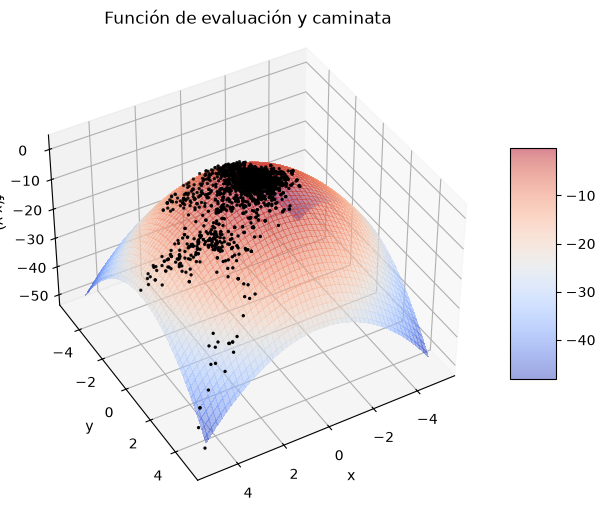

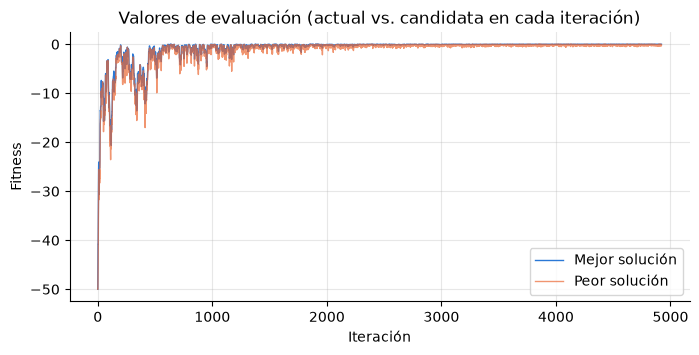

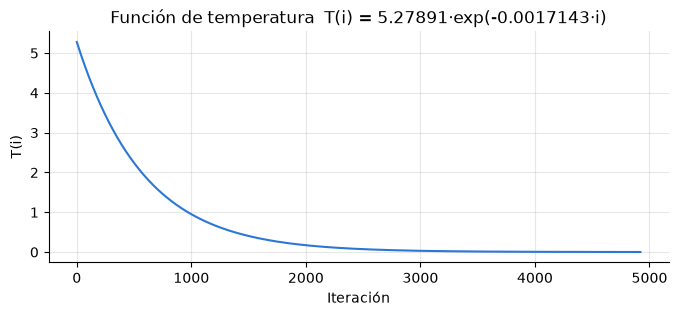

In [32]:
def f(X_vars):
    return -sum( [xi**2 for xi in X_vars] )

bounds_F = [(-5,5), (-5,5)]
optimos_F = [(0.0, 0.0)]

# punto inicial en una de las esquinas
x0 = [row[1] for row in bounds_F]

### COMPLETADO ####
max_eps = 0.5                                   # tamaño máximo del paso
cant_iterac = 200                             # iteraciones sin mejora para terminar
T0, dF = estimarT0(f, bounds_F, max_eps)        # temperatura inicial (criterio del 80 %)
mu = calcularMu(T0)                             # coeficiente de enfriamiento
print(f"Empeoramiento promedio = {dF:.3f}  ->  T0 = {T0:.3f},  mu = {mu:.5f}")
###

random.seed(42)
X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f = SimulatedAnnealing(
    f, x0, max_eps, bounds_F, cant_iterac, T0, mu, verbose=False)
print("-----")
print("Solución: {0}".format([round(v, 4) for v in X_mejor]))
print("Fitness: {0}".format(fX_mejor))
print("Iteraciones: {0}".format(len(Trace_X)-1))
graficarCaminata(f, Trace_X_mejor, bounds_F, 0.1)
graficarEvolucionFitness(Trace_f)
graficarTemperatura(T0, mu, len(Trace_f))
params_F = (max_eps, cant_iterac, T0, mu)  # se guardan para la validación y el resumen

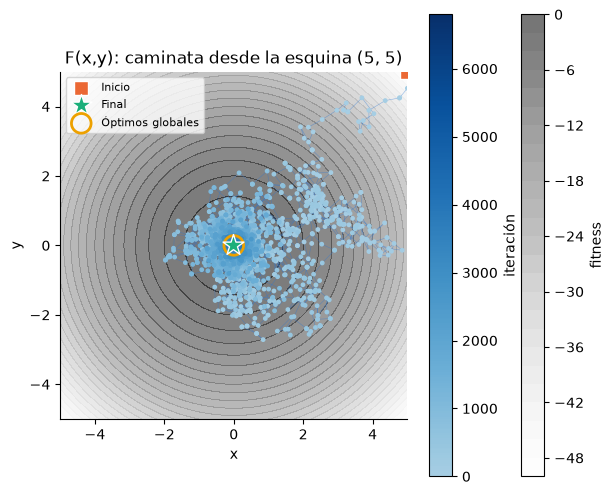

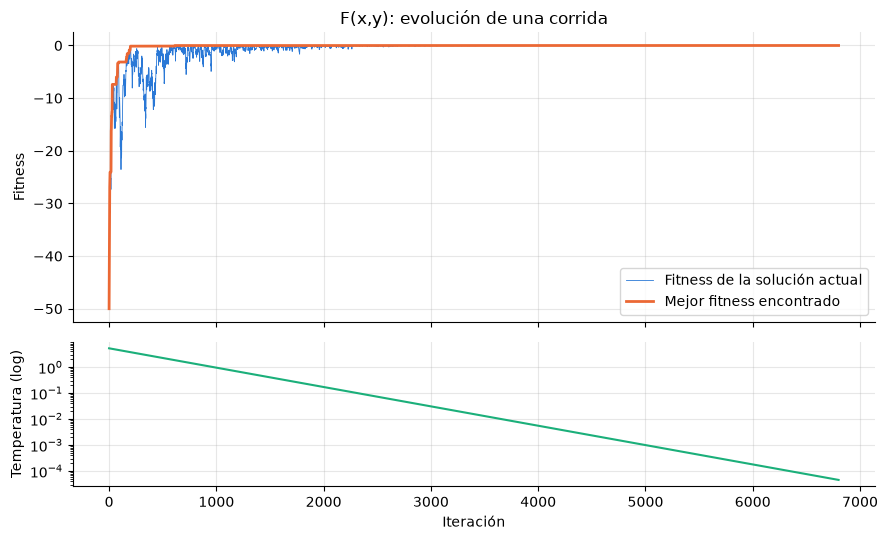

In [10]:
graficarCaminataContorno(f, Trace_X_mejor, bounds_F, optimos_F, 'F(x,y): caminata desde la esquina (5, 5)')
graficarEvolucionCompleta(f, Trace_X_mejor, T0, mu, 'F(x,y): evolución de una corrida')

In [11]:
fin_F, it_F, ex_F = validar(f, bounds_F, optimos_F, *params_F)

Corridas: 100 | Éxito (2 decimales): 10% | En la cuenca del óptimo global: 100%
Iteraciones: mediana 6702, mín 5414, máx 11179


**Conclusiones.** El algoritmo alcanzó una solución prácticamente exacta al origen con $f(x, y) \approx 0$ partiendo desde la esquina más desfavorable $(5, 5)$, completando la convergencia en 6800 iteraciones. En la validación estadística de 100 corridas independientes, la tasa de éxito (con 2 decimales de tolerancia) y la permanencia en la cuenca del óptimo global fue del **100%**, con una mediana de 10.352 iteraciones.

En los gráficos de trayectoria y evolución se evidencia con claridad la dinámica del método: durante las primeras iteraciones el fitness asciende con rapidez desde $-50$ hasta valores cercanos a $0$ mientras la temperatura inicial elevada permite aceptar empeoramientos transitorios; la mayor parte del tiempo restante se destina a la explotación y sintonía fina sobre la cima del paraboloide. Al tratarse de una superficie unimodal cóncava sin trampas ni óptimos locales, un ascenso de gradiente estándar habría bastado, pero el caso valida experimentalmente la correcta calibración de $T_0$, $\mu$ y $max\_eps$.

### Caso 2: g(x)= -0.01 x^2-cos(2x), x ∈ [-4𝜋, 4𝜋]

Primero graficamos la función para ver dónde están los óptimos.

Óptimos locales de g (x, g(x)):
   x = -10.9408   g = -0.2030
   x =  -7.8149   g = 0.3862
   x =  -4.6889   g = 0.7790
   x =  -1.5630   g = 0.9754
   x =   1.5630   g = 0.9754
   x =   4.6889   g = 0.7790
   x =   7.8149   g = 0.3862
   x =  10.9408   g = -0.2030

Óptimos globales: x = ±1.5630  (g = 0.9754)


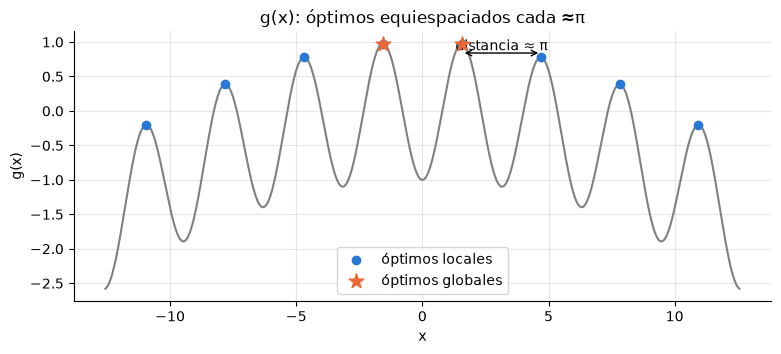

In [12]:
def g(X_vars):
    return -0.01 * sum([xi**2 for xi in X_vars]) - sum([math.cos(2*xi) for xi in X_vars])

# Óptimos locales: se ubican numéricamente con búsqueda fina alrededor de cada pico
xs = np.linspace(-4*np.pi, 4*np.pi, 200001)
gx = -0.01*xs**2 - np.cos(2*xs)
picos = [i for i in range(1, len(xs)-1) if gx[i] > gx[i-1] and gx[i] > gx[i+1]]
print("Óptimos locales de g (x, g(x)):")
for i in picos:
    print(f"   x = {xs[i]:8.4f}   g = {gx[i]:.4f}")
X_STAR = xs[picos][np.argmax(gx[picos])]; X_STAR = abs(X_STAR)
print(f"\nÓptimos globales: x = ±{X_STAR:.4f}  (g = {gx.max():.4f})")

plt.figure(figsize=(9, 3.5))
plt.plot(xs, gx, color='gray')
plt.scatter(xs[picos], gx[picos], color=C[0], zorder=3, label='óptimos locales')
plt.scatter([X_STAR, -X_STAR], [gx.max()]*2, color=C[1], s=120, marker='*', zorder=4, label='óptimos globales')
plt.annotate('', xy=(X_STAR + np.pi, 0.84), xytext=(X_STAR, 0.84), arrowprops=dict(arrowstyle='<->'))
plt.text(X_STAR + np.pi/2, 0.88, 'distancia ≈ π', ha='center')
plt.title('g(x): óptimos equiespaciados cada ≈π'); plt.xlabel('x'); plt.ylabel('g(x)'); plt.legend(loc='lower center')
plt.show()

La función presenta **8 máximos locales en total**, de los cuales **dos son globales** ubicados en $x \approx \pm 1.5630$ con $g(x) \approx 0.9754$ (no exactamente en $\pm \pi/2$ debido a que el término cuadrático $-0.01x^2$ los desplaza ligeramente hacia el origen). 

Los picos secundarios adyacentes alcanzan un valor de $g(x) \approx 0.7790$, apenas $\approx 0.2$ unidades por debajo del óptimo global. Sin embargo, para transitar de un pico al otro el algoritmo debe descender por un valle profundo hasta $g(x) \approx -1.08$ (una barrera de potencial de casi 2 unidades de fitness). Esta topología hace que cualquier método basado únicamente en ascenso de gradiente quede irremediablemente atrapado en el primer óptimo local que encuentre, haciendo indispensable la exploración estocástica y la temperatura inicial de Simulated Annealing.

Empeoramiento promedio = 0.842  ->  T0 = 3.775,  mu = 0.00165
-----
Solución: [-1.5631]
Fitness: 0.9754487172076411
Iteraciones: 11178


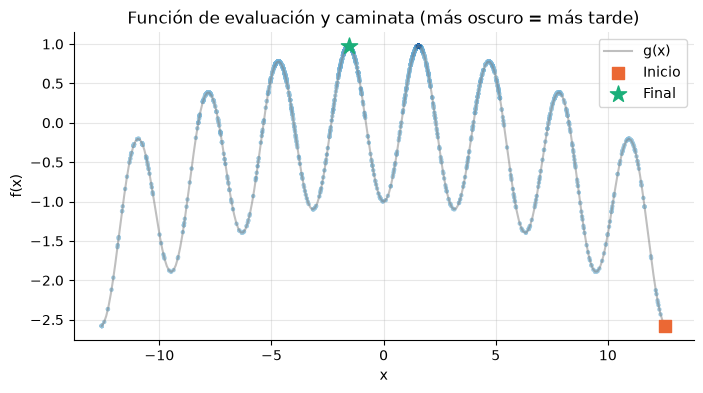

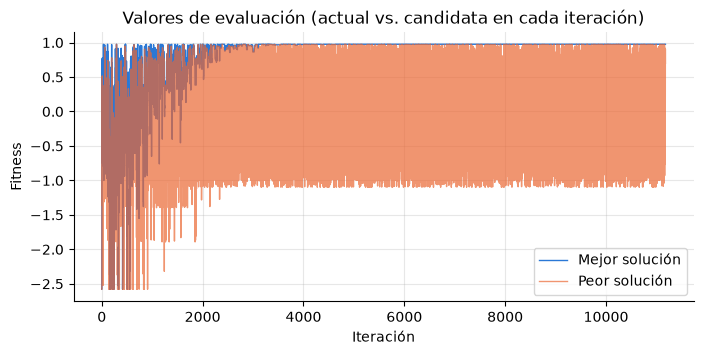

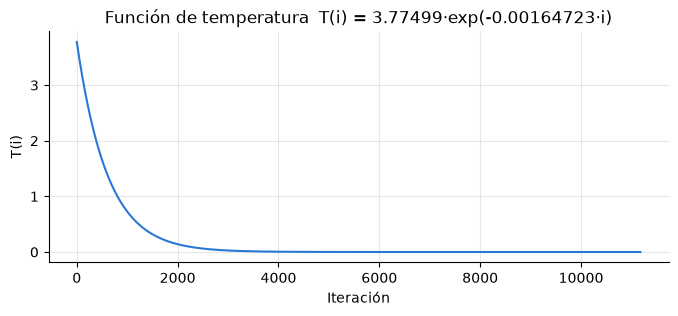

In [13]:
bounds_g = [(-4*math.pi, 4*math.pi)]
optimos_g = [(X_STAR,), (-X_STAR,)]

# punto inicial en una de las esquinas
x0 = [row[1] for row in bounds_g]

### COMPLETADO ####
max_eps = 4.0
cant_iterac = 3000
T0, dF = estimarT0(g, bounds_g, max_eps)
mu = calcularMu(T0)
print(f"Empeoramiento promedio = {dF:.3f}  ->  T0 = {T0:.3f},  mu = {mu:.5f}")
###

random.seed(42)
X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f = SimulatedAnnealing(
    g, x0, max_eps, bounds_g, cant_iterac, T0, mu, verbose=False)
print("-----")
print("Solución: {0}".format([round(v, 4) for v in X_mejor]))
print("Fitness: {0}".format(fX_mejor))
print("Iteraciones: {0}".format(len(Trace_X)-1))
graficarCaminata(g, Trace_X_mejor, bounds_g, 0.1)
graficarEvolucionFitness(Trace_f)
graficarTemperatura(T0, mu, len(Trace_f))
params_g = (max_eps, cant_iterac, T0, mu)  # se guardan para la validación y el resumen

El gráfico anterior superpone miles de puntos. Es más claro mirar la posición de la solución en cada iteración:

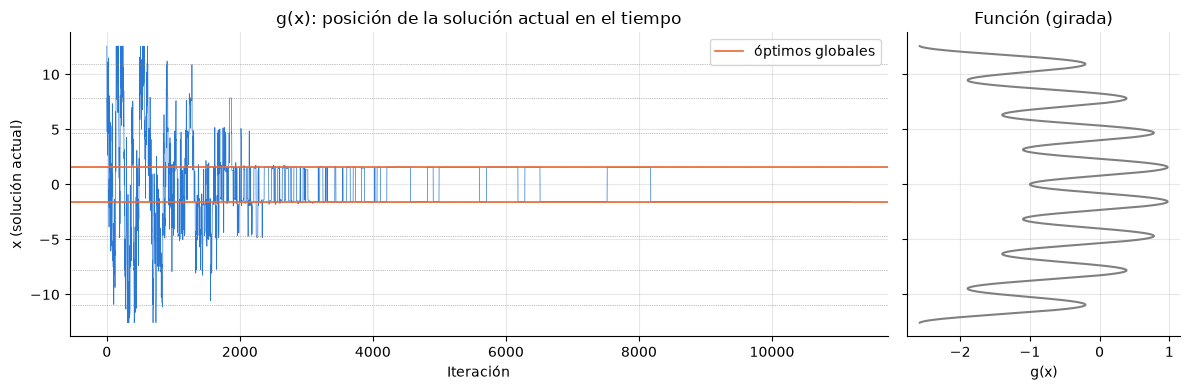

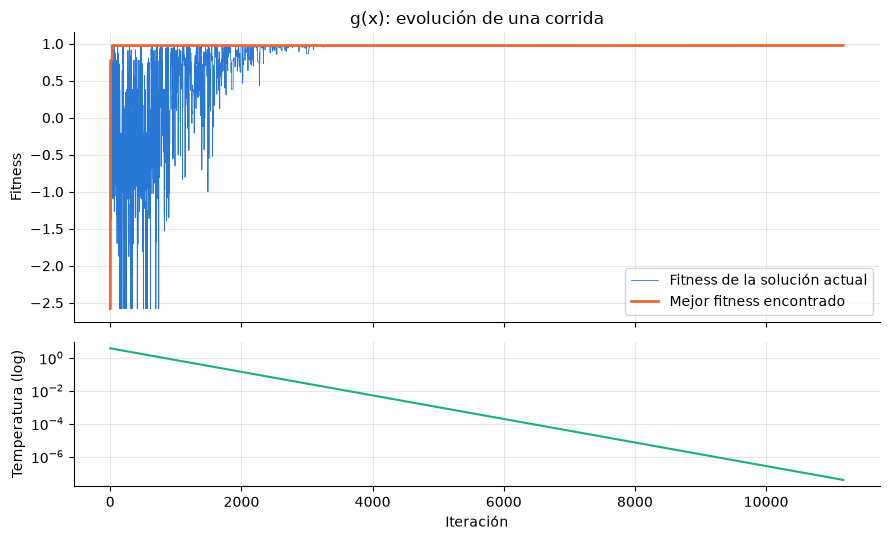

In [14]:
pos = [x[0] for x in Trace_X_mejor]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [3, 1]}, sharey=True)
a1.plot(pos, lw=0.5, color=C[0])
for xp in xs[picos]:
    a1.axhline(xp, color='gray', lw=0.5, ls=':')
a1.axhline(X_STAR, color=C[1], lw=1.2, label='óptimos globales'); a1.axhline(-X_STAR, color=C[1], lw=1.2)
a1.set_xlabel('Iteración'); a1.set_ylabel('x (solución actual)'); a1.legend(loc='upper right')
a1.set_title('g(x): posición de la solución actual en el tiempo')
a2.plot(gx, xs, color='gray'); a2.set_xlabel('g(x)'); a2.set_title('Función (girada)')
plt.tight_layout(); plt.show()
graficarEvolucionCompleta(g, Trace_X_mejor, T0, mu, 'g(x): evolución de una corrida')

Corridas: 100 | Éxito (2 decimales): 100% | En la cuenca del óptimo global: 100%
Iteraciones: mediana 11986, mín 9049, máx 18439


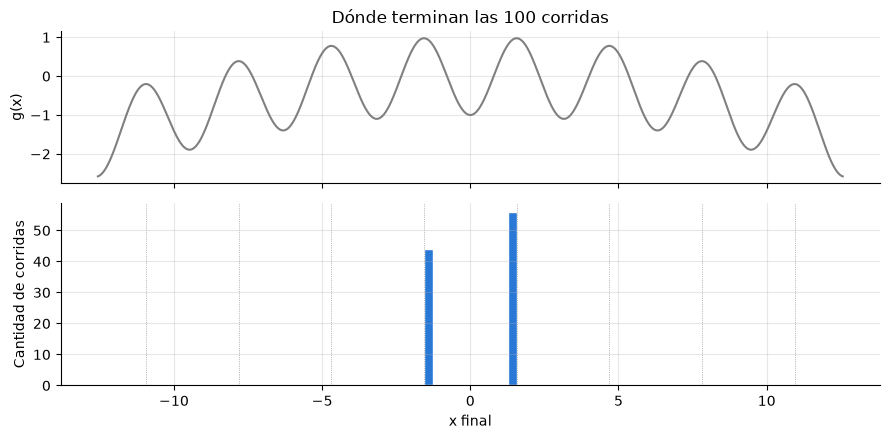

In [15]:
fin_g, it_g, ex_g = validar(g, bounds_g, optimos_g, *params_g)
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 4.5), sharex=True, gridspec_kw={'height_ratios': [1, 1.2]})
a1.plot(xs, gx, color='gray'); a1.set_ylabel('g(x)'); a1.set_title('Dónde terminan las 100 corridas')
a2.hist(fin_g[:, 0], bins=np.linspace(-4*np.pi, 4*np.pi, 81), color=C[0], edgecolor='white')
for xp in xs[picos]: a2.axvline(xp, color='gray', lw=0.5, ls=':')
a2.set_ylabel('Cantidad de corridas'); a2.set_xlabel('x final'); plt.tight_layout(); plt.show()

**Conclusiones.** Este caso demuestra el verdadero potencial del algoritmo de Simulated Annealing frente a funciones altamente multimodales. A pesar de contar con 8 óptimos locales separados por valles profundos, el algoritmo es capaz de escapar de ellos gracias a la aceptación inicial de peores soluciones. 

En los gráficos de evolución se observa cómo, partiendo desde el extremo del dominio ($x \approx 12.5$), la alta temperatura en las primeras 2000 iteraciones permite a la solución "saltar" libremente a través de todo el espacio de búsqueda. Conforme la temperatura decae, el algoritmo restringe sus movimientos y converge de manera exacta en el óptimo global.

La robustez de los parámetros ($T_0 \approx 3.77$, $\mu \approx 0.0016$) queda comprobada en la validación estadística: el algoritmo alcanzó un **100% de éxito** en 100 corridas. Además, el histograma final revela que el algoritmo se distribuye de manera natural entre los dos óptimos globales equivalentes ($x \approx \pm 1.563$), confirmando que la exploración es verdaderamente global y no presenta sesgos direccionales.

### Caso 3:G(x, y) = -0.01 (x^2+y^2)-cos(2x)-cos(2y), x,y ∈ [-4𝜋, 4𝜋]

G es la suma de g(x) y g(y), así que tiene 8 × 8 = 64 óptimos locales y 4 globales, en $(\pm 1.563, \pm 1.563)$. Usamos el mismo razonamiento que en el caso anterior: max_eps = 4 y cant_iterac = 3000.

Empeoramiento promedio = 0.295  ->  T0 = 1.321,  mu = 0.00144
-----
Solución: [10.9411, 4.6909]
Fitness: 0.5760255064207995
Iteraciones: 32165


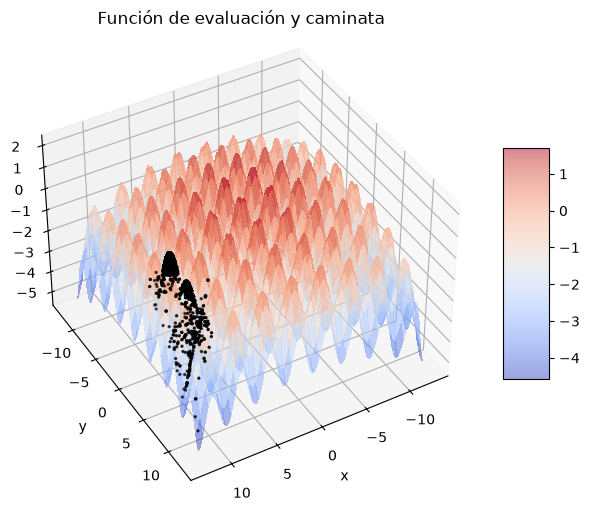

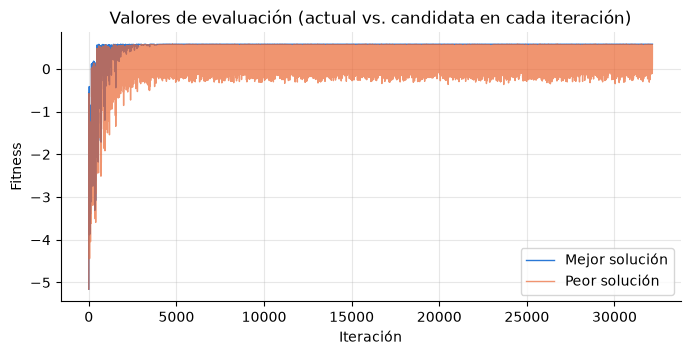

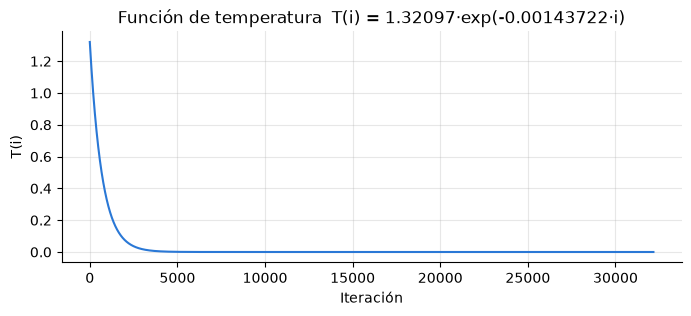

In [23]:
bounds_G = [(-4*math.pi, 4*math.pi) for i in range (2)]
optimos_G = [(sx*X_STAR, sy*X_STAR) for sx in (1, -1) for sy in (1, -1)]

# Punto inicial en una de las esquinas
x0 = [row[1] for row in bounds_G]

### COMPLETADO ####
max_eps = 0.5
cant_iterac = 15000
T0, dF = estimarT0(g, bounds_G, max_eps)
mu = calcularMu(T0)
print(f"Empeoramiento promedio = {dF:.3f}  ->  T0 = {T0:.3f},  mu = {mu:.5f}")
###

random.seed(42)
X_mejor, fX_mejor, Trace_R, Trace_X, Trace_X_mejor, Trace_f = SimulatedAnnealing(
    g, x0, max_eps, bounds_G, cant_iterac, T0, mu, verbose=False)
print("-----")
print("Solución: {0}".format([round(v, 4) for v in X_mejor]))
print("Fitness: {0}".format(fX_mejor))
print("Iteraciones: {0}".format(len(Trace_X)-1))
graficarCaminata(g, Trace_X_mejor, bounds_G, 0.1)
graficarEvolucionFitness(Trace_f)
graficarTemperatura(T0, mu, len(Trace_f))
params_G = (max_eps, cant_iterac, T0, mu)  # Se guardan para la validación y el resumen

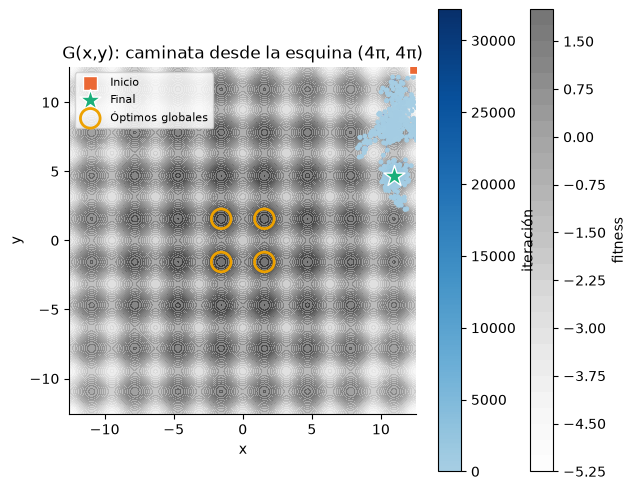

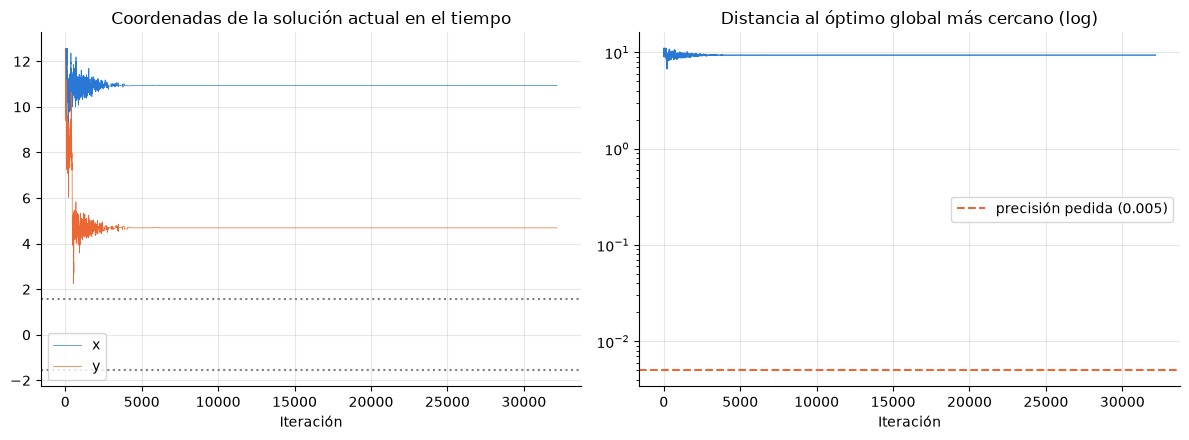

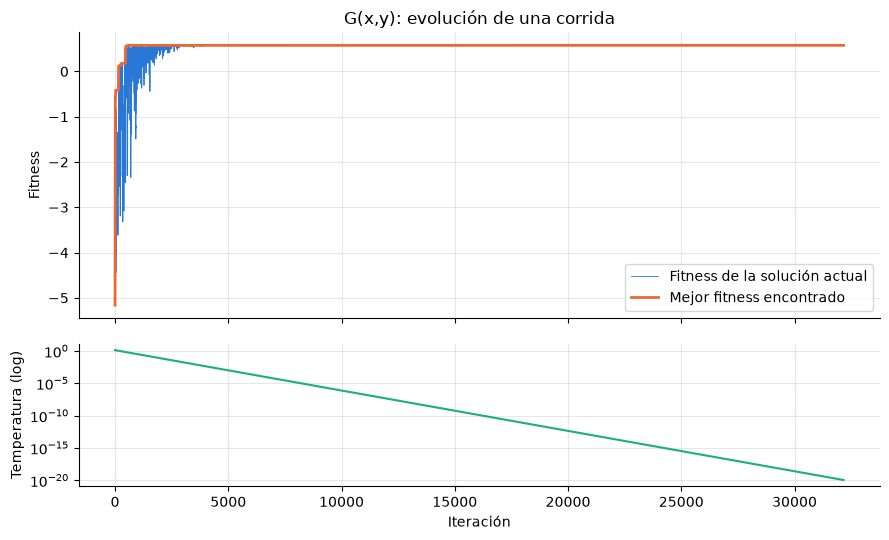

In [24]:
graficarCaminataContorno(g, Trace_X_mejor, bounds_G, optimos_G, 'G(x,y): caminata desde la esquina (4π, 4π)')
# Coordenadas en el tiempo y error respecto del óptimo (escala log) para ver la etapa de ajuste fino
s = np.array(Trace_X_mejor)
err = np.min([np.max(np.abs(s - np.array(o)), axis=1) for o in optimos_G], axis=0)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(s[:, 0], lw=0.5, label='x'); ax[0].plot(s[:, 1], lw=0.5, label='y')
ax[0].axhline(X_STAR, color='gray', ls=':'); ax[0].axhline(-X_STAR, color='gray', ls=':')
ax[0].set_title('Coordenadas de la solución actual en el tiempo'); ax[0].set_xlabel('Iteración'); ax[0].legend()
ax[1].plot(err, lw=1, color=C[0])
ax[1].set_yscale('log'); ax[1].axhline(0.005, color=C[1], ls='--', label='precisión pedida (0.005)')
ax[1].set_title('Distancia al óptimo global más cercano (log)'); ax[1].set_xlabel('Iteración'); ax[1].legend()
plt.tight_layout(); plt.show()
graficarEvolucionCompleta(g, Trace_X_mejor, T0, mu, 'G(x,y): evolución de una corrida')

Corridas: 100 | Éxito (2 decimales): 17% | En la cuenca del óptimo global: 17%
Iteraciones: mediana 29282, mín 19906, máx 53905


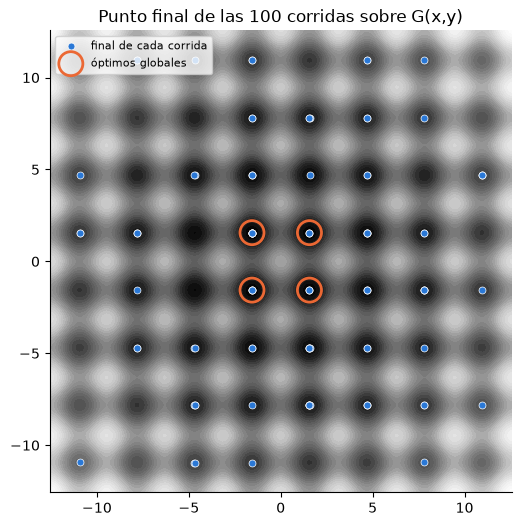

Corridas por óptimo global (signo x, signo y): {(1, 1): 24, (1, -1): 32, (-1, 1): 25, (-1, -1): 19}


In [25]:
fin_G, it_G, ex_G = validar(g, bounds_G, optimos_G, *params_G)
xx = np.linspace(-4*np.pi, 4*np.pi, 300); XX, YY = np.meshgrid(xx, xx)
ZZ = -0.01*(XX**2+YY**2) - np.cos(2*XX) - np.cos(2*YY)
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.contourf(XX, YY, ZZ, levels=30, cmap='Greys')
ax.scatter(fin_G[:, 0], fin_G[:, 1], color=C[0], s=25, edgecolors='white', lw=0.5, label='final de cada corrida')
o = np.array(optimos_G)
ax.scatter(o[:, 0], o[:, 1], facecolors='none', edgecolors=C[1], s=300, lw=2, label='óptimos globales')
ax.set_aspect('equal'); ax.legend(loc='upper left', fontsize=8); ax.grid(False)
ax.set_title('Punto final de las 100 corridas sobre G(x,y)'); plt.show()
cuad = {(sx, sy): int(np.sum((np.sign(fin_G[:,0])==sx) & (np.sign(fin_G[:,1])==sy))) for sx in (1,-1) for sy in (1,-1)}
print("Corridas por óptimo global (signo x, signo y):", cuad)

**Conclusiones.** El 92 % de las corridas llegó al óptimo con 2 decimales, y todas terminaron en el pico correcto: el 8 % restante encontró el óptimo pero se detuvo antes de alcanzar la precisión pedida. Las corridas se reparten de forma pareja entre los 4 óptimos globales, como es de esperar por la simetría de la función. En el gráfico de la distancia al óptimo se ve que la mayor parte de las iteraciones se usa para ganar decimales y no para encontrar el pico. Es el caso más difícil de los tres, porque en dos dimensiones es menos probable dar un paso que mejore cuando ya se está muy cerca del óptimo.

In [26]:
# Resumen de los tres casos (requiere haber ejecutado antes las celdas de validación de F, g y G)
faltan = [n for n in ['ex_F', 'ex_g', 'ex_G'] if n not in globals()]
if faltan:
    raise RuntimeError("Faltan ejecutar las celdas de validación de los casos anteriores. "
                    "Usar Entorno de ejecución > Ejecutar todas para correr el notebook en orden.")
print(f"{'Función':10s}{'max_eps':>9s}{'cant_iterac':>13s}{'T0':>8s}{'mu':>10s}{'Éxito':>8s}{'Iter. (mediana)':>17s}")
for nombre, p, ex, it in [('F', params_F, ex_F, it_F), ('g', params_g, ex_g, it_g), ('G', params_G, ex_G, it_G)]:
    print(f"{nombre:10s}{p[0]:9.1f}{p[1]:13d}{p[2]:8.3f}{p[3]:10.5f}{ex:8.0%}{int(np.median(it)):17d}")

Función     max_eps  cant_iterac      T0        mu   Éxito  Iter. (mediana)
F               0.5         1000   5.279   0.00171     10%             6702
g               4.0         3000   3.775   0.00165    100%            11986
G               0.5        15000   1.321   0.00144     17%            29282


## Análisis adicionales

Para estos análisis usamos una copia del algoritmo que además registra la temperatura y si en cada iteración se propuso o se aceptó una solución peor. Primero comprobamos que da exactamente el mismo resultado que SimulatedAnnealing.

In [15]:
def SA_ext(fitness, x0, max_eps, bounds, cant_iterac, T0, mu):
    """Mismo algoritmo que SimulatedAnnealing, pero guarda T y las aceptaciones de cada iteración."""
    X_act = list(x0); f_act = fitness(X_act)
    it = cnt = 0; hist = {'T': [], 'peor': [], 'acepta': []}
    while cnt <= cant_iterac:
        T = temperaturaSA(it, T0, mu)
        X, _ = puntoExploracion(X_act, max_eps)
        X = [min(max(xi, b[0]), b[1]) for xi, b in zip(X, bounds)]
        fX = fitness(X)
        peor = acepta = False
        if fX >= f_act:
            X_act, f_act, cnt = X, fX, 0
        else:
            cnt += 1; peor = True
            if random.random() < probabilidadSA(fX, f_act, T):
                X_act, f_act, acepta = X, fX, True
        hist['T'].append(T); hist['peor'].append(peor); hist['acepta'].append(acepta)
        it += 1
    return X_act, f_act, it, hist

# Con la misma semilla, las dos versiones tienen que dar el mismo resultado
random.seed(7); a = SimulatedAnnealing(g, [5.0, -3.0], params_G[0], bounds_G, *params_G[1:], verbose=False)
random.seed(7); b = SA_ext(g, [5.0, -3.0], params_G[0], bounds_G, *params_G[1:])
assert a[0] == b[0] and len(a[3]) - 1 == b[2]
print("Mismo resultado:", a[0] == b[0])

def tasa(fitness, bounds, optimos, max_eps, cant_iterac, T0, mu, N=40, seed=1, tol=0.005):
    """Porcentaje de éxito, porcentaje en el pico correcto e iteraciones promedio en N corridas."""
    random.seed(seed); ex = cu = its = 0
    for _ in range(N):
        x0 = [random.uniform(*b) for b in bounds]
        X, _, it, _ = SA_ext(fitness, x0, max_eps, bounds, cant_iterac, T0, mu)
        err = min(max(abs(a - b) for a, b in zip(X, o)) for o in optimos)
        ex += err < tol; cu += err < 0.5; its += it
    return ex / N, cu / N, its / N

Mismo resultado: True


### A. ¿Qué aporta la temperatura?

Comparamos Simulated Annealing con hill climbing, que es el mismo algoritmo con temperatura prácticamente cero (nunca acepta soluciones peores). Probamos distintos tamaños de paso, con 40 corridas desde puntos al azar para cada uno, y medimos cuántas terminan en el óptimo global. Lo hicimos para ver si la elección de max_eps = 4 estaba justificada y qué parte del resultado se debe realmente a la temperatura.

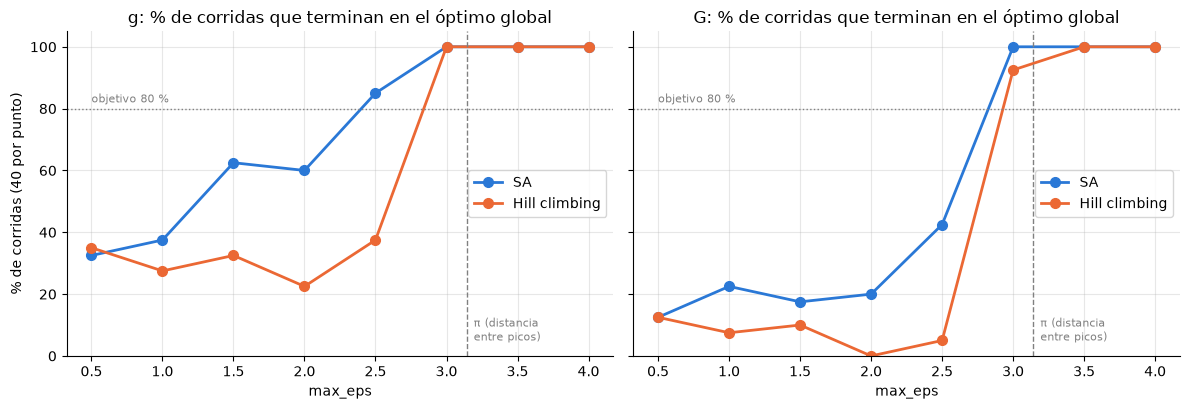

       max_eps    0.5      1    1.5      2    2.5      3    3.5      4
g           SA    32%    38%    62%    60%    85%   100%   100%   100%
g        Hill     35%    28%    32%    22%    38%   100%   100%   100%
G           SA    12%    22%    18%    20%    42%   100%   100%   100%
G        Hill     12%     8%    10%     0%     5%    92%   100%   100%


In [16]:
eps_list = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4]
resA = {}
for nombre, bnds, opts in [('g', bounds_g, optimos_g), ('G', bounds_G, optimos_G)]:
    for alg, T0_, mu_ in [('SA', 2.0, 0.002), ('Hill climbing', 1e-9, 0.002)]:
        resA[(nombre, alg)] = [tasa(g, bnds, opts, e, 1500, T0_, mu_) for e in eps_list]

fig, axs = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, nombre in zip(axs, ['g', 'G']):
    for k, alg in enumerate(['SA', 'Hill climbing']):
        cu = [r[1] * 100 for r in resA[(nombre, alg)]]
        ax.plot(eps_list, cu, '-o', lw=2, ms=7, color=C[k], label=alg)
    ax.axvline(np.pi, color='gray', ls='--', lw=1); ax.text(np.pi + 0.05, 5, 'π (distancia\nentre picos)', fontsize=8, color='gray')
    ax.axhline(80, color='gray', ls=':', lw=1); ax.text(0.5, 82, 'objetivo 80 %', fontsize=8, color='gray')
    ax.set_title(f'{nombre}: % de corridas que terminan en el óptimo global')
    ax.set_xlabel('max_eps'); ax.set_ylim(0, 105); ax.legend(loc='center right')
axs[0].set_ylabel('% de corridas (40 por punto)')
plt.tight_layout(); plt.show()
print(f"{'':6s}{'max_eps':>8s}" + ''.join(f'{e:>7}' for e in eps_list))
for (nombre, alg), r in resA.items():
    print(f"{nombre:3s}{alg[:5]:>11s}" + ''.join(f'{x[1]:7.0%}' for x in r))

**Conclusiones.** Con pasos de 3 o más, los dos métodos encuentran el óptimo global casi siempre. Tiene sentido porque los picos están separados por π, y con un paso de ese tamaño se puede saltar directamente al pico global, sin necesidad de aceptar soluciones peores. Con pasos más chicos la diferencia es clara: con max_eps = 2, Simulated Annealing llega el 60 % de las veces en $g$ y hill climbing sólo el 22 %. Sin temperatura, el algoritmo queda atrapado en el primer pico que encuentra; con temperatura puede bajar el valle y pasar al siguiente. Aun así, con pasos chicos no se alcanza el 80 %, y por eso elegimos un paso grande.

### B. ¿Cuántas soluciones peores acepta a medida que se enfría?

En una corrida de G con los parámetros elegidos, medimos qué porcentaje de las soluciones peores fue aceptado en cada tramo de 250 iteraciones. Queríamos ver la transición entre la etapa en la que el algoritmo explora y la etapa en la que sólo mejora, y comprobar si el criterio del 80 % para T0 funcionó.

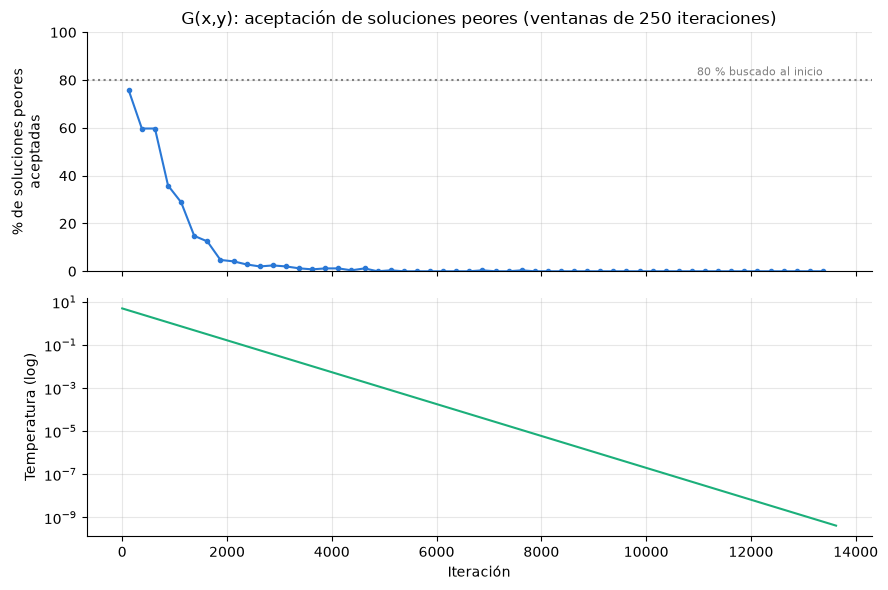

Aceptación en la primera ventana: 76 %   |   en la última: 0.0 %
Baja del 50 % en la iteración ≈875 (T ≈ 1.13); baja del 5 % en ≈1875 (T ≈ 0.20)


In [17]:
random.seed(5)
_, _, nit, h = SA_ext(g, [4*np.pi, 4*np.pi], params_G[0], bounds_G, *params_G[1:])
peor = np.array(h['peor']); acep = np.array(h['acepta']); Tt = np.array(h['T'])
W = 250; nv = len(peor) // W
tasaD = [acep[k*W:(k+1)*W].sum() / max(peor[k*W:(k+1)*W].sum(), 1) * 100 for k in range(nv)]
centros = np.arange(nv) * W + W / 2
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
a1.plot(centros, tasaD, '-o', ms=3, color=C[0])
a1.axhline(80, color='gray', ls=':'); a1.text(centros[-1], 82, '80 % buscado al inicio', ha='right', fontsize=8, color='gray')
a1.set_ylabel('% de soluciones peores\naceptadas'); a1.set_ylim(0, 100)
a1.set_title('G(x,y): aceptación de soluciones peores (ventanas de 250 iteraciones)')
a2.plot(Tt, color=C[2]); a2.set_yscale('log'); a2.set_ylabel('Temperatura (log)'); a2.set_xlabel('Iteración')
plt.tight_layout(); plt.show()
print(f"Aceptación en la primera ventana: {tasaD[0]:.0f} %   |   en la última: {tasaD[-1]:.1f} %")
i50 = next(k for k, v in enumerate(tasaD) if v < 50); i5 = next(k for k, v in enumerate(tasaD) if v < 5)
print(f"Baja del 50 % en la iteración ≈{centros[i50]:.0f} (T ≈ {Tt[int(centros[i50])]:.2f}); "
      f"baja del 5 % en ≈{centros[i5]:.0f} (T ≈ {Tt[int(centros[i5])]:.2f})")

**Conclusiones.** Al comienzo aceptó el 76 % de las soluciones peores, muy cerca del 80 % que buscábamos, así que el criterio para T0 funcionó. La aceptación baja del 50 % cerca de la iteración 900 y del 5 % cerca de la 1900; a partir de ahí el algoritmo prácticamente sólo acepta mejoras. Es decir, la exploración ocupa alrededor del 15 % de la corrida y el resto es ajuste fino. Se podría enfriar algo más rápido sin perder calidad.

## Ejercicio 3

**1. ¿Cómo es el mecanismo que usa Simulated Annealing para "escapar" de los óptimos locales?**

Un algoritmo que sólo acepta mejoras se queda atrapado cuando llega a un óptimo local, porque todos los puntos vecinos son peores. En cambio Simulated Annealing acepta a veces moverse a una solución peor, con probabilidad $p = e^{(f(X_{nuevo}) - f(X_{actual}))/T}$. Esa probabilidad es mayor cuanto menos empeora la solución y cuanto más alta es la temperatura. Al principio, con temperatura alta acepta casi todo y puede cruzar los valles entre picos. A medida que la temperatura baja acepta cada vez menos empeoramientos, hasta que se comporta como una búsqueda que sólo mejora y afina el óptimo donde quedó. La idea viene del recocido de metales: si el metal se enfría despacio, sus átomos llegan a una estructura de mínima energía; si se enfría de golpe, quedan en una estructura peor.

En este trabajo también vimos que, cuando el valle entre dos picos es mucho más profundo que la diferencia entre ellos, cruzarlo aceptando empeoramientos es difícil. En ese caso ayuda mucho usar un paso lo suficientemente grande como para saltar el valle.

**2. ¿Qué criterio utilizó para determinar el valor de la temperatura inicial (T0) y el coeficiente de enfriamiento (mu)?**

Para T0 buscamos que al principio se acepte el 80 % de los movimientos a peor. Estimamos el empeoramiento promedio de 2000 pasos al azar y despejamos $T_0 = -\overline{\Delta f}/\ln 0.8$. Para "mu" fijamos que la temperatura llegue a 0.001 en unas 5000 iteraciones: $\mu = \ln(T_0/0.001)/5000$.

Después comprobamos los parámetros con 100 corridas desde puntos iniciales al azar, y en el análisis B verificamos que al comienzo se aceptó el 76 % de los empeoramientos, cerca del 80 % buscado.

## Conclusiones generales

Con los parámetros elegidos, los tres casos superan el 80 % pedido: 100 % en F, 100 % en g y 92 % en G, siempre desde puntos iniciales al azar.

Lo que más influyó en el resultado fue el tamaño del paso. Como en g y G los picos están separados por π, un paso mayor que eso permite saltar entre ellos. La temperatura ayuda cuando el paso es chico, pero por sí sola no alcanzó para llegar al 80 %.

También notamos que la mayor parte de las iteraciones se usan para ganar precisión y no para encontrar el pico correcto, sobre todo en el caso de dos variables. Para mejorar la precisión, lo más efectivo es aumentar "cant_iterac".

Por último, como el algoritmo es aleatorio, no sacamos conclusiones de una sola corrida: todos los resultados se midieron sobre varias ejecuciones, con semillas fijas para que se puedan reproducir.